# Purpose

The purpose of this example notebook is to show how to use the `spectra` package for spectrum analysis and calculating the normalized dose as a function of `z`. This notebook will walk through a more complex example useing multiple absorbers and multiple wavelength sources.

# Imports

In [1]:
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget

import spectra.data as data
from spectra.resin import ResinConstituentAbsorber, ResinConstituentMonomer, Resin
from spectra.irradiance import Irradiance
from spectra.utilities import ArrayParams
from spectra.normalizeddose import NormalizedDose

## Define constants

In [2]:
# linearly spaced wavelength values from 300 to 440 nm
wavelengths = np.linspace(*ArrayParams(300, 480, 361))

# z values for normalized dose calculations
z_array_params_15_0 = ArrayParams(0, 150, 201)
z_array_params_1_5 = ArrayParams(0, 15, 201)

## Define constituent materials

In [3]:
monomer = ResinConstituentMonomer(data.monomers['Ideal'], 100)
absorber = ResinConstituentAbsorber(
    data.absorbers['ideal_uniform_absorber_320nm-390nm'],
    1
)

## Create resins

In [4]:
resin = Resin(monomers=monomer, absorbers=absorber)

## Define Sources

In [5]:
source_365nm = data.sources['ideal_uniform_source_360nm-370nm']
source_405nm = data.sources['ideal_uniform_source_400nm-410nm']

# Final Resin Absorbtion

Text(0.5, 1.0, 'Ide-100__Uni-1__')

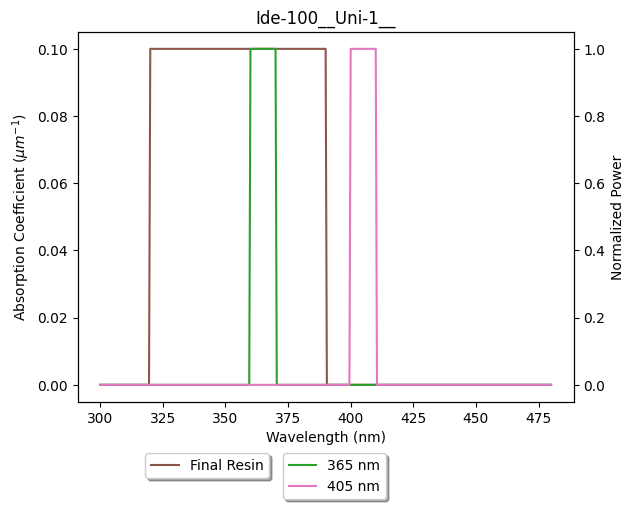

In [6]:
fig, ax = plt.subplots()
ln1 = ax.plot(wavelengths, resin.calc_absorption_coef_inv_um(wavelengths), c='C5', label="Final Resin")
ax.set_xlabel('Wavelength (nm)', weight=500)
ax.set_ylabel('Absorption Coefficient (${\mu m}^{-1}$)', weight=500)
# ax.legend(loc='upper left')

# ax.set_title(nps.name + '\n' + source.name)
ax2 = ax.twinx()
ln3 = ax2.plot(wavelengths, source_365nm.calc_power(wavelengths), c='C2', label='365 nm')
ln4 = ax2.plot(wavelengths, source_405nm.calc_power(wavelengths), c='C6', label='405 nm')
ax2.set_ylabel('Normalized Power', weight=500)
# ax2.legend(loc='upper right')

lns = ln1+ln3+ln4
labs = [l.get_label() for l in lns]
ax.legend(loc='upper right', bbox_to_anchor=(0.4, -0.12), ncol=1, fancybox=True, shadow=True)
ax2.legend(loc='upper left', bbox_to_anchor=(0.4, -0.12), ncol=1, fancybox=True, shadow=True)
# ax.legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, fancybox=True, shadow=True)

ax.set_title(resin.name)


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Ide-100__Uni-1__\nideal_uniform_source_400nm-410nm'}, xlabel='z ($\\mu$m)', ylabel="D'(z)">)

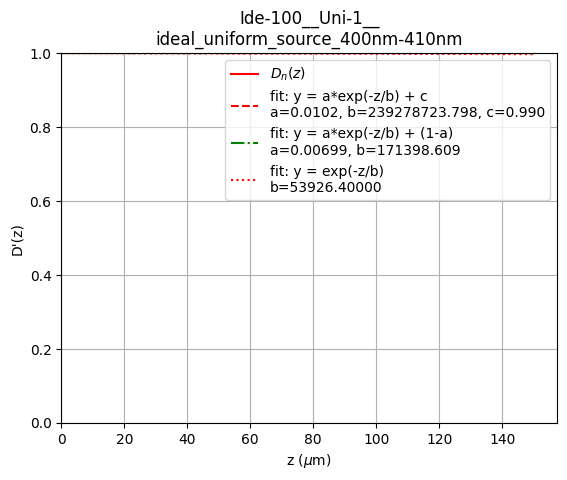

In [7]:
irradiance_405nm = Irradiance(
    source=source_405nm, 
    resin=resin, 
    wavelength_array_params=ArrayParams(300, 470, 601)
)
norm_dose_405nm = NormalizedDose(
    irradiance=irradiance_405nm, 
    z_array_params=z_array_params_15_0
)

norm_dose_405nm.plot(
    title=(
        resin.name +
        "\n" +
        source_405nm.name
    )
)


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Ide-100__Uni-1__\nideal_uniform_source_360nm-370nm'}, xlabel='z ($\\mu$m)', ylabel="D'(z)">)

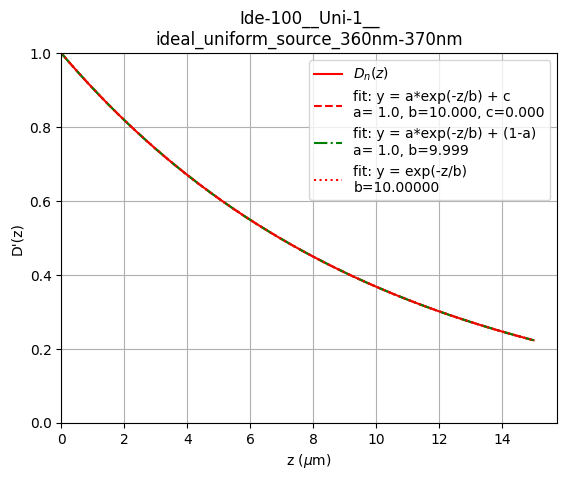

In [8]:
irradiance_365nm = Irradiance(
    source=source_365nm, 
    resin=resin, 
    wavelength_array_params=ArrayParams(300, 470, 601)
)
norm_dose_365nm = NormalizedDose(
    irradiance=irradiance_365nm, 
    z_array_params=z_array_params_1_5
)

norm_dose_365nm.plot(
    title=(
        resin.name +
        "\n" +
        source_365nm.name
    )
)